## Exercise 1: Population Structure Analysis using SNPs

### 1. Plink convert and filtering

Convert VCF into binary format with PLINK

In [ ]:
!plink --vcf input.vcf.gz --make-bed --out data_chr1

Filter out low quality variants and samples. 

In [ ]:
!plink --bfile data_chr1 \
      --maf 0.05 \
      --geno 0.05 \
      --mind 0.05 \
      --hwe 1e-6 \
      --make-bed \
      --out dataset_chr1_qc

### 2. LD Pruning

In [ ]:
!plink --bfile dataset_chr1_qc \
      --indep-pairwise 50 5 0.2 \
      --out pruned

Extract pruned SNPs.

In [ ]:
!plink --bfile dataset_chr1_qc \
      --extract pruned.prune.in \
      --make-bed \
      --out dataset_chr1_pruned

### 3. Principal component analysis

In [ ]:
!plink --bfile dataset_chr1_pruned \
      --pca 10 \
      --out pca_results

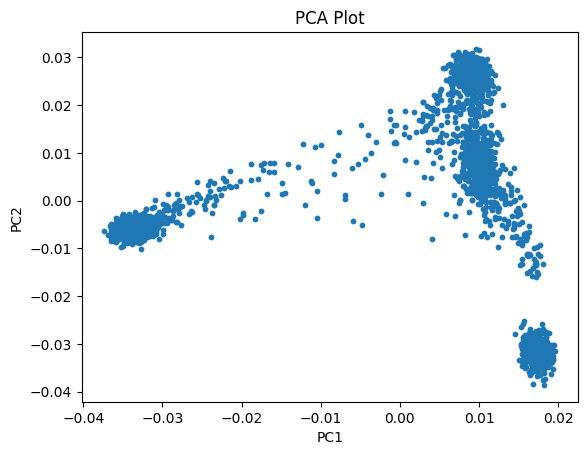

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pca = pd.read_csv("pca_results.eigenvec", sep=r"\s+", header=None)

# Assign column names
cols = ["FID", "IID"] + [f"PC{i}" for i in range(1, pca.shape[1]-1)]
pca.columns = cols

# Plot PC1 vs PC2
plt.figure()
plt.scatter(pca["PC1"], pca["PC2"], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot")
plt.show()

Make PCA with population info

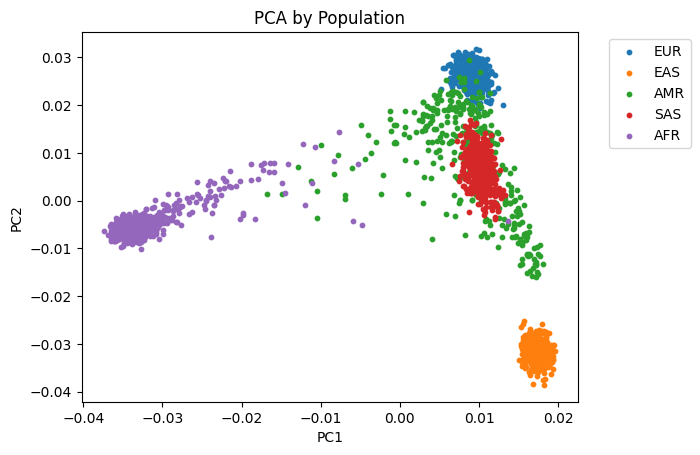

In [2]:
# Load population info
pop = pd.read_csv("integrated_call_samples_v3.20130502.ALL.panel", sep=r"\s+")

# Merge on sample ID
merged = pca.merge(pop, left_on="IID", right_on="sample")
(merged)
# Plot with colors by population
plt.figure()

for group in merged["super_pop"].unique():
    subset = merged[merged["super_pop"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA by Population")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Admixture analysis

Choosing right K:

In [ ]:
!for K in 5 6 7 8; do
  admixture -j8 dataset_chr1_pruned.bed $K | tee log${K}.out
done
# I did it on a reduced number of k and without cv because the running took very long

Plot likelihoods to find best K

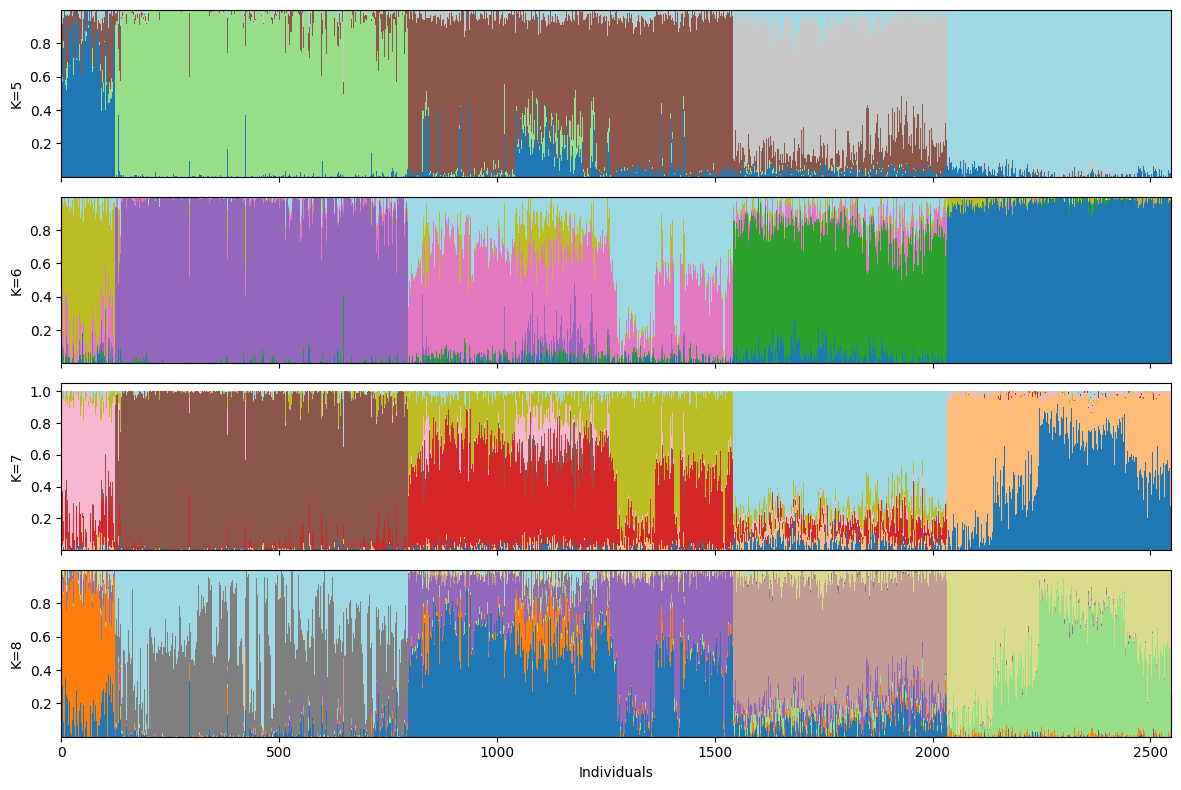

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob


prefix = "dataset_chr1_pruned"
Ks = [5, 6, 7, 8]


Q_matrices = {}
for K in Ks:
    Q_matrices[K] = np.loadtxt(f"{prefix}.{K}.Q")

n_samples = Q_matrices[Ks[0]].shape[0]

# set K=5 as reference
ref_K = Ks[0]
ref_Q = Q_matrices[ref_K]

# sort individuals by dominant ancestry at K=5
order = np.argsort(np.argmax(ref_Q, axis=1))


# PLOT

fig, axes = plt.subplots(len(Ks), 1, figsize=(12, 2 * len(Ks)), sharex=True)

if len(Ks) == 1:
    axes = [axes]

for ax, K in zip(axes, Ks):
    Q = Q_matrices[K][order]

    bottom = np.zeros(n_samples)
    colors = plt.cm.tab20(np.linspace(0, 1, K))

    for k in range(K):
        ax.bar(range(n_samples),
               Q[:, k],
               bottom=bottom,
               color=colors[k],
               width=1.0,
               edgecolor='none')
        bottom += Q[:, k]

    ax.set_ylabel(f"K={K}")
    ax.set_xlim(0, n_samples)

axes[-1].set_xlabel("Individuals")

plt.tight_layout()
plt.savefig("admixture_all_K.png", dpi=300)
plt.show()

It seems that K=5 or K=6 are best suited. I will use both for future analysis and then compare the 2. K=7 and K=8 seem to have overfitting and are less suited. Ideally, I should have ran ADMIXTURE with cv to choose the right K, but that would have taken too long.

#### Plot of Admixture with K=6

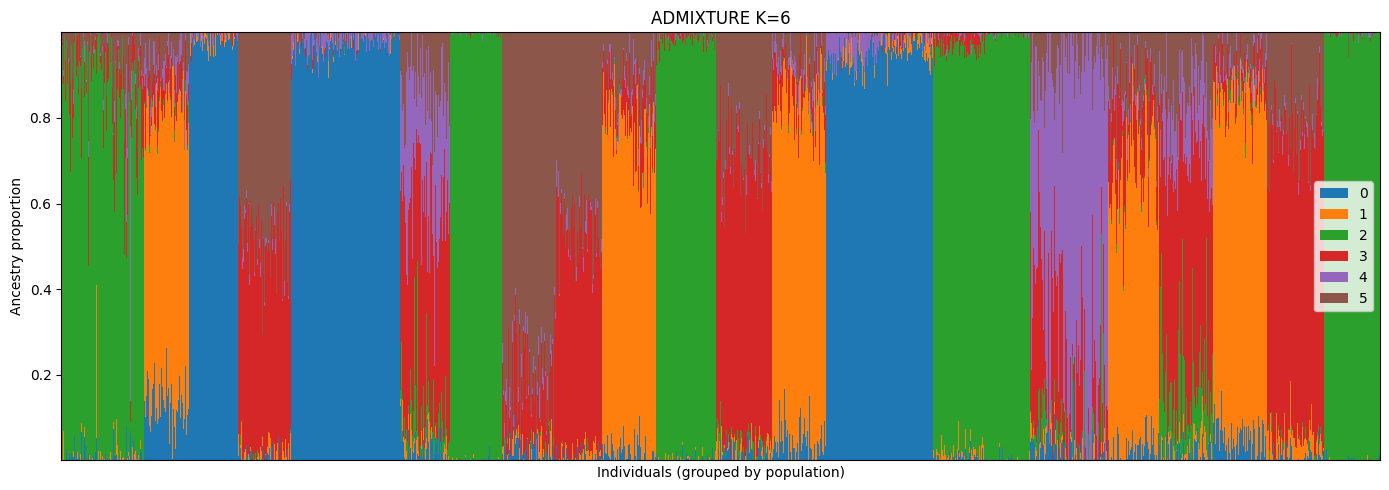

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Q matrix (no header)
Q6 = pd.read_csv("dataset_chr1_pruned.6.Q", sep=r"\s+", header=None)

# Load sample IDs from .fam
fam = pd.read_csv("dataset_chr1_pruned.fam", sep=r"\s+", header=None)
Q6["IID"] = fam[1]

# Plot stacked barplot
Q6_values = Q6.drop(columns=["IID"])

# Load population panel
panel = pd.read_csv("integrated_call_samples_v3.20130502.ALL.panel", sep=r"\s+")

# Merge
merged6 = Q6.merge(panel, left_on="IID", right_on="sample")

# Sort individuals by population
merged6 = merged6.sort_values("pop")

# Extract ancestry columns
Q_values6 = merged6.iloc[:, :-5] 

# Plot
Q_values6.plot(kind="bar", stacked=True, width=1, figsize=(14,5))

plt.xlabel("Individuals (grouped by population)")
plt.ylabel("Ancestry proportion")
plt.title("ADMIXTURE K=6")
plt.xticks([])  # hide crowded labels
plt.tight_layout()
plt.show()

#### Plot of Admixture with K=5

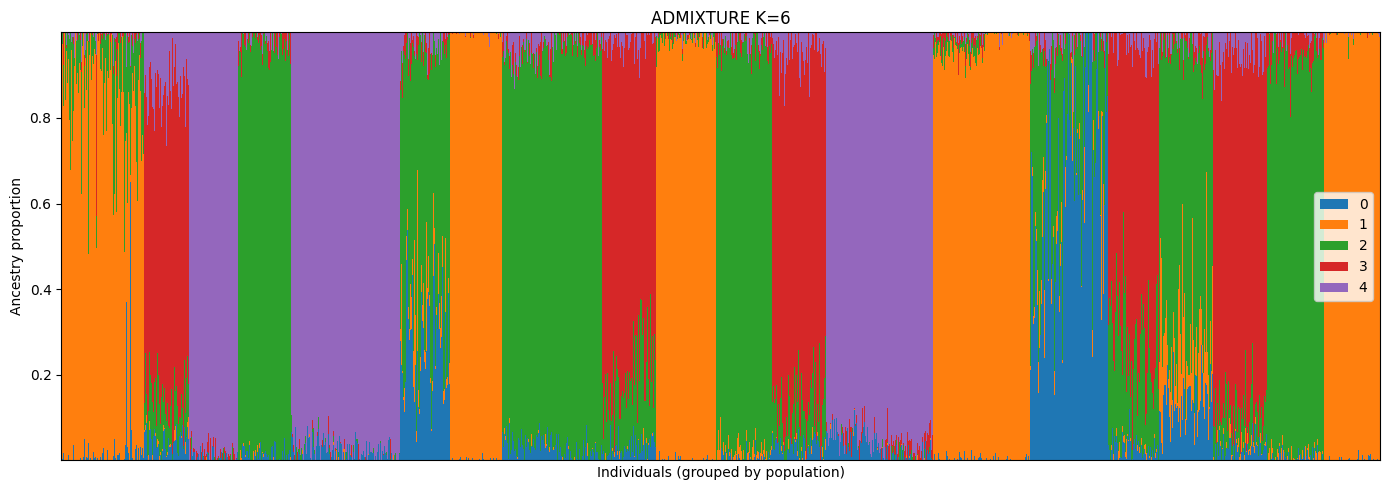

In [4]:
# Load Q matrix (no header)
Q5 = pd.read_csv("dataset_chr1_pruned.5.Q", sep=r"\s+", header=None)

Q5["IID"] = fam[1]

# Plot stacked barplot
Q5_values = Q5.drop(columns=["IID"])

# Merge
merged5 = Q5.merge(panel, left_on="IID", right_on="sample")

# Sort individuals by population
merged5 = merged5.sort_values("pop")

# Extract ancestry columns
Q_values5 = merged5.iloc[:, :-5]  

# Plot
Q_values5.plot(kind="bar", stacked=True, width=1, figsize=(14,5))

plt.xlabel("Individuals (grouped by population)")
plt.ylabel("Ancestry proportion")
plt.title("ADMIXTURE K=6")
plt.xticks([])  # hide crowded labels
plt.tight_layout()
plt.show()

#### Admixture analysis by population for K=6

In [6]:
# Select only ancestry columns
K = Q6.shape[1]
Q_cols6 = list(range(K-1))

# Compute mean ancestry per population
pop_means6 = merged6.groupby("super_pop")[Q_cols6].mean()
print(pop_means6)

                  0         1         2         3         4         5
super_pop                                                            
AFR        0.004997  0.005717  0.939762  0.024974  0.006189  0.018360
AMR        0.022671  0.019349  0.079765  0.371448  0.393615  0.113152
EAS        0.961749  0.010307  0.000619  0.002668  0.021919  0.002737
EUR        0.012826  0.020995  0.005823  0.504999  0.013102  0.442255
SAS        0.054571  0.738130  0.005691  0.083100  0.028307  0.090201


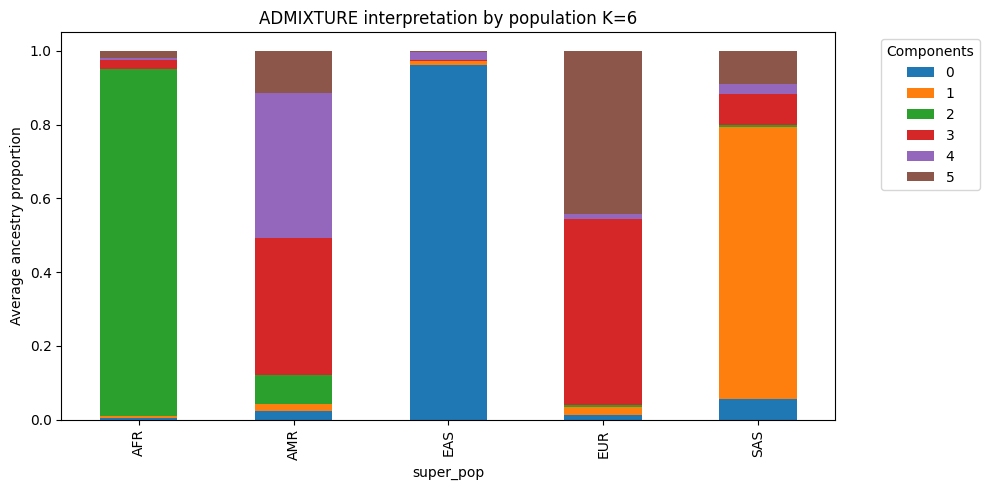

In [7]:
import matplotlib.pyplot as plt

pop_means6.plot(kind="bar", stacked=True, figsize=(10,5))

plt.ylabel("Average ancestry proportion")
plt.title("ADMIXTURE interpretation by population K=6")
plt.legend(title="Components", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

#### Admixture analysis by population for K=5

In [9]:
#Select only ancestry columns
K5 = Q5.shape[1]
Q_cols5 = list(range(K5-1))

# Compute mean ancestry per population
pop_means5 = merged5.groupby("super_pop")[Q_cols5].mean()
print(pop_means5)

                  0         1         2         3         4
super_pop                                                  
AFR        0.006459  0.941761  0.039639  0.006820  0.005321
AMR        0.390690  0.083303  0.482263  0.021975  0.021769
EAS        0.021809  0.000738  0.003017  0.010742  0.963695
EUR        0.017155  0.007540  0.931080  0.026815  0.017411
SAS        0.030514  0.006208  0.132873  0.772943  0.057461


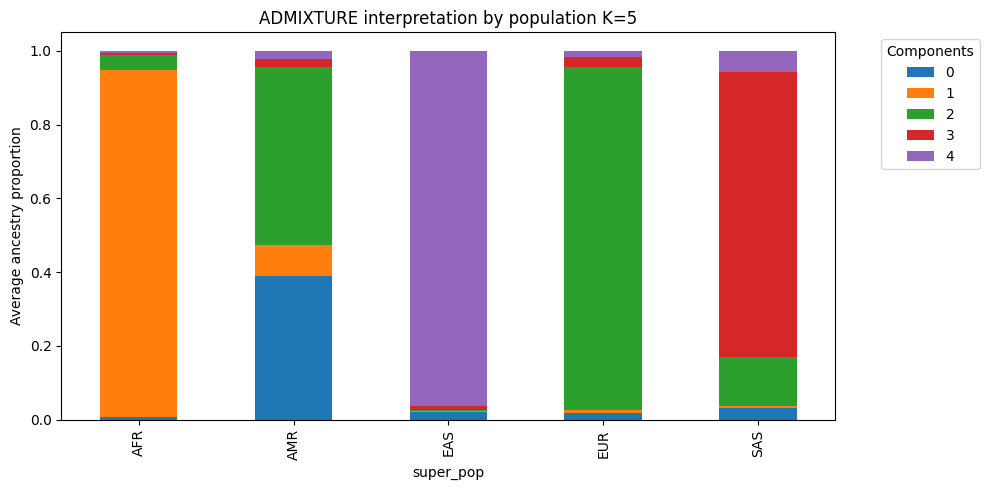

In [11]:
import matplotlib.pyplot as plt

pop_means5.plot(kind="bar", stacked=True, figsize=(10,5))

plt.ylabel("Average ancestry proportion")
plt.title("ADMIXTURE interpretation by population K=5")
plt.legend(title="Components", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()